In [187]:
import numpy as np

from tucker_tensor import TuckerDecomposition, ExtendedTucker

dataset = "fineweb-en"
random_state = 1
tucker = TuckerDecomposition.load_from_disk(
    dataset=dataset,
    method="siiSoftPlus",
    divergence="fr",
    dims=2000,
    rank=150,
    iterations=500
)

In [81]:
from similarity import load_og_sentences
from utils import DATA_DIR
import os

vector_path = os.path.join(DATA_DIR, "vectors", "fineweb_english_vectors.csv")
full_dataset = load_og_sentences(vector_path=vector_path)

In [188]:
extended = ExtendedTucker.extend_tucker(
    tucker,
    dataset=full_dataset,
    roles=["verb", "subject"],
    min_count=25,
    fraction_threads=0.66,
    normalize=False
)

calculating reps (subject): 100%|██████████| 411809/411809 [01:11<00:00, 5742.06it/s]


In [83]:
norm_extended = ExtendedTucker.extend_tucker(
    tucker,
    dataset=full_dataset,
    roles=["verb", "subject"],
    min_count=25,
    fraction_threads=0.66,
    normalize=True
)

[7.8839602e-09 4.7917141e-09 3.5800385e-10 ... 1.2247449e-11 1.2247449e-11
 1.2247449e-11]
target norm: 1.9101279585820308e-11


calculating reps (verb): 100%|██████████| 7718/7718 [00:01<00:00, 5531.10it/s]


[3.0408829e-09 1.1535336e-09 3.7973460e-10 ... 1.2533694e-11 1.2513498e-11
 1.2247449e-11]
target norm: 1.3370306597981774e-11


calculating reps (subject): 100%|██████████| 411809/411809 [01:09<00:00, 5953.46it/s]


In [103]:
norm_extended = ExtendedTucker.extend_tucker(
    tucker,
    dataset=full_dataset,
    roles=["verb", "subject"],
    min_count=25,
    fraction_threads=0.66,
    normalize=True,
    normalize_mode="l2"
)

calculating reps (subject): 100%|██████████| 411809/411809 [01:07<00:00, 6077.70it/s]


In [90]:
alt_extended = ExtendedTucker.extend_tucker(
    tucker,
    dataset=full_dataset,
    roles=["verb", "subject"],
    min_count=25,
    fraction_threads=0.66,
    normalize=True,
    normalize_mode="minmax"
)

calculating reps (subject): 100%|██████████| 411809/411809 [01:07<00:00, 6063.36it/s]


In [139]:
alt_extended_bis = ExtendedTucker.extend_tucker(
    tucker,
    dataset=full_dataset,
    roles=["verb", "subject"],
    min_count=25,
    fraction_threads=0.66,
    normalize=True,
    normalize_mode="minmax"
)

calculating reps (subject): 100%|██████████| 411809/411809 [01:08<00:00, 5997.41it/s]


In [6]:
norm_extended.extension_lengths

{'verb': 369, 'subject': 2475, 'object': 2625}

In [104]:
norm_extended.extensions["verb"]

{'accessibility': array([1.69273370e-15, 2.39815369e-16, 9.65093388e-14, 6.32310989e-16,
        7.26406690e-16, 3.36368283e-14, 6.27164584e-15, 2.34511188e-15,
        2.22008423e-16, 3.45736232e-16, 2.69231043e-15, 2.06071601e-12,
        4.38664225e-14, 1.61485373e-15, 9.22606893e-15, 1.82007282e-15,
        3.31970855e-14, 9.67711940e-17, 6.78165557e-15, 2.18319904e-13,
        1.12457512e-14, 1.87906165e-16, 4.91238027e-16, 1.12689970e-16,
        7.22462957e-14, 5.89440082e-15, 4.03769197e-14, 2.72235792e-16,
        1.53443617e-13, 4.97143301e-14, 1.38967206e-16, 1.77468058e-12,
        2.60706846e-16, 3.40408799e-15, 8.95579359e-14, 6.45416344e-16,
        2.05827165e-14, 4.55730982e-16, 1.03159463e-13, 8.39890495e-16,
        6.80444829e-14, 1.77805603e-14, 7.70789928e-14, 1.91215411e-14,
        1.02069064e-16, 2.14955561e-16, 5.13270584e-13, 1.96622478e-13,
        2.41957127e-12, 7.70520368e-14, 2.99563437e-13, 1.23056677e-16,
        1.62888418e-13, 7.69670386e-16, 1.01629

In [68]:
extended.extensions["verb"]

{'scrap': array([1.58143031e+05, 2.15704351e+05, 3.64021713e+02, 2.29751016e+05,
        8.83252343e+04, 4.71026305e+04, 1.08380051e+05, 2.47800123e+03,
        7.76545155e+04, 3.54010958e+05, 1.51277629e+04, 9.25736670e+04,
        2.53886305e+02, 4.19067845e+04, 8.34435509e+03, 6.47015901e+05,
        2.61023429e+02, 1.81856440e+04, 1.86891205e+02, 3.08423874e+03,
        1.20035335e+05, 1.84592668e+04, 1.61083327e+05, 5.78492069e+03,
        5.36519170e+04, 1.38649619e+03, 9.43128966e+04, 2.10039806e+05,
        3.44162068e+04, 2.83897537e+05, 2.23774927e+05, 5.36803924e+04,
        1.12122295e+05, 2.42813023e+05, 2.17076112e+05, 3.71847030e+03,
        1.32899429e+03, 7.31568730e+02, 2.59376695e+05, 2.29714661e+04,
        2.54441829e+05, 1.99985116e+03, 5.14144798e+05, 2.17136438e+05,
        3.30140841e+05, 3.19422244e+01, 8.71682050e+04, 7.86881701e+04,
        2.19119600e+04, 3.61097141e+01, 6.95652929e+01, 7.65241133e+05,
        4.14764728e+05, 1.91103863e+05, 1.63318140e+02,

In [69]:
norm_extended.extensions["verb"]


{'obey': array([2.26322065e-09, 8.30819307e-09, 2.74459025e-12, 1.06842976e-08,
        1.20808637e-09, 2.16195262e-09, 2.31291557e-09, 6.13548508e-10,
        2.84070075e-09, 1.52302551e-08, 1.43892717e-10, 1.45296656e-09,
        2.87308830e-12, 1.00682238e-09, 3.99064154e-11, 1.26411747e-09,
        3.50060137e-12, 7.13875152e-11, 6.23310836e-12, 7.84475624e-12,
        2.17040191e-09, 5.45620515e-10, 1.87832796e-09, 3.87090046e-09,
        1.42573712e-09, 3.71040204e-11, 2.78106244e-09, 1.31457672e-08,
        6.25552638e-10, 1.89100067e-08, 7.87241299e-09, 9.70083234e-10,
        2.49803004e-09, 1.60555373e-09, 4.70232312e-09, 6.63760791e-10,
        9.05081883e-12, 1.73484763e-11, 3.40366111e-09, 1.26428940e-09,
        3.03063652e-09, 1.26321011e-11, 2.88147418e-09, 4.57472942e-09,
        8.25130376e-09, 8.72430816e-13, 2.97850995e-09, 1.11761667e-08,
        5.42180922e-10, 1.39056958e-12, 1.94897813e-12, 1.48839695e-08,
        1.40100305e-08, 6.36401777e-09, 1.58117509e-11, 

In [70]:
norm_extended.extensions["verb"]["broadcast"].max()

np.float64(2.2398591191596023e-08)

In [71]:
tucker.factors[0][0].max()

tensor(7.6665e-07)

In [73]:
norm_extended.save_extensions(DATA_DIR/"tensors"/dataset/"extensions/extension_norm_test.pt")

In [10]:
vocab_v = extended.vocab["vocab_v"]
print(len(vocab_v))
print(len(extended.extended_tokens["verb"]))
vocab_v.extend(extended.extended_tokens["verb"])
len(vocab_v)

1000
369


1369

In [25]:
tucker_extended = norm_extended.integrate_extension(None)

{'verb': 18, 'subject': 2104, 'object': 1998}


In [26]:
tucker_extended.get_top_words_for_dimension("verb", 0)

[('ensure', 1.7670325291874178e-07),
 ('guarantee', 3.8701490012726936e-08),
 ('prioritize', 1.7981584221615776e-08),
 ('deliver', 6.867046931091636e-09),
 ('facilitate', 6.44598063814783e-09),
 ('maintain', 5.791784385422716e-09),
 ('allow', 5.688747251042514e-09),
 ('compromise', 4.505344097793795e-09),
 ('promote', 4.504802753046988e-09),
 ('combine', 4.0716692240039265e-09)]

In [98]:
from tucker_tensor import np_sim
import numpy as np
# we calculate the similarity between the elements
test_set = ["king", "man", "woman", "queen", "dog", "pc"]
for el in test_set:
    print(f"{el} in vocab: {el in tucker.vocab['vocab_s']}")

for i, el in enumerate(test_set):
    lat = norm_extended.fetch_single_latent(el, "subject")
    # we normalise this to 0-1
    for j, el2 in enumerate(test_set):
        lat2 = norm_extended.fetch_single_latent(el2, "subject")
        print(f"similarity {el}-{el2} = {np_sim(lat, lat2)}")


king in vocab: True
man in vocab: True
woman in vocab: True
queen in vocab: False
dog in vocab: True
pc in vocab: False
similarity king-king = 1.0
similarity king-man = 0.7851585745811462
similarity king-woman = 0.7882887721061707
similarity king-queen = 0.1736312048089626
similarity king-dog = 0.9598939418792725
similarity king-pc = 0.15539303194278792
similarity man-king = 0.7851585745811462
similarity man-man = 1.0
similarity man-woman = 0.9999386668205261
similarity man-queen = 0.7048671555463412
similarity man-dog = 0.9272963404655457
similarity man-pc = 0.5351391003009334
similarity woman-king = 0.7882887721061707
similarity woman-man = 0.9999386668205261
similarity woman-woman = 1.0000001192092896
similarity woman-queen = 0.7016532363489754
similarity woman-dog = 0.9291607141494751
similarity woman-pc = 0.5328597867279303
similarity queen-king = 0.1736312048089626
similarity queen-man = 0.7048671555463412
similarity queen-woman = 0.7016532363489754
similarity queen-queen = 1.000

In [112]:
from tucker_tensor import np_sim
import numpy as np
# we calculate the similarity between the elements
test_set = ["king", "man", "woman", "queen", "dog", "pc"]
for el in test_set:
    print(f"{el} in vocab: {el in tucker.vocab['vocab_s']}")

for i, el in enumerate(test_set):
    lat = alt_extended_bis.fetch_single_latent(el, "subject")
    # we normalise this to 0-1
    for j, el2 in enumerate(test_set):
        lat2 = alt_extended_bis.fetch_single_latent(el2, "subject")
        print(f"similarity {el}-{el2} = {np_sim(lat, lat2)}")


king in vocab: True
man in vocab: True
woman in vocab: True
queen in vocab: False
dog in vocab: True
pc in vocab: False
similarity king-king = 1.0
similarity king-man = 0.7851585745811462
similarity king-woman = 0.7882887721061707
similarity king-queen = 0.7164429629305435
similarity king-dog = 0.9598939418792725
similarity king-pc = 0.9408822160663202
similarity man-king = 0.7851585745811462
similarity man-man = 1.0
similarity man-woman = 0.9999386668205261
similarity man-queen = 0.5287533197576316
similarity man-dog = 0.9272963404655457
similarity man-pc = 0.707554572468645
similarity woman-king = 0.7882887721061707
similarity woman-man = 0.9999386668205261
similarity woman-woman = 1.0000001192092896
similarity woman-queen = 0.531431546150161
similarity woman-dog = 0.9291607141494751
similarity woman-pc = 0.7101588852310187
similarity queen-king = 0.7164429629305435
similarity queen-man = 0.5287533197576316
similarity queen-woman = 0.531431546150161
similarity queen-queen = 1.0000000

In [113]:
from tucker_tensor import np_sim
import numpy as np
# we calculate the similarity between the elements
test_set = ["king", "man", "woman", "queen"]

for i, el in enumerate(test_set):
    lat = norm_extended.fetch_single_latent(el, "subject")
    # we normalise this to 0-1
    for j, el2 in enumerate(test_set):
        lat2 = norm_extended.fetch_single_latent(el2, "subject")
        print(f"similarity {el}-{el2} = {np_sim(lat, lat2)}")


similarity king-king = 1.0
similarity king-man = 0.7851585745811462
similarity king-woman = 0.7882887721061707
similarity king-queen = 0.17363120480896257
similarity man-king = 0.7851585745811462
similarity man-man = 1.0
similarity man-woman = 0.9999386668205261
similarity man-queen = 0.7048671555463412
similarity woman-king = 0.7882887721061707
similarity woman-man = 0.9999386668205261
similarity woman-woman = 1.0000001192092896
similarity woman-queen = 0.7016532363489755
similarity queen-king = 0.17363120480896257
similarity queen-man = 0.7048671555463412
similarity queen-woman = 0.7016532363489755
similarity queen-queen = 0.9999999999999999


# Informed aggregation

In [92]:
for i in range(10):
    top = alt_extended.get_top_words_for_dimension("subject", i)
    print("\n", i)
    for el, score in top:
        print(el, el in tucker.vocab["vocab_s"], score)


 0
he True 3.5952546495465754e-10
placement True 5.2430084579446756e-11
lack True 4.2734368127517186e-11
adaptability True 3.7831338756122435e-11
optimization True 3.644459040108572e-11
she True 3.562745584662075e-11
integration True 3.259091607699105e-11
quality True 3.09608068349565e-11
advancement True 3.0059416761263336e-11
disruption True 2.983208818863048e-11

 1
he True 4.986085988534228e-10
placement True 7.250703509820156e-11
optimization True 6.019817977431785e-11
lack True 5.908520894770675e-11
alignment True 4.24434966339593e-11
adaptability True 4.204693537790405e-11
advancement True 3.98663810297073e-11
quality True 3.4476910909519987e-11
integration True 3.3999882770308076e-11
disruption True 3.333417569750807e-11

 2
he True 1.379329428452536e-09
she True 5.212508202845356e-11
placement True 3.777998400233962e-11
Quality True 3.6497135175173057e-11
lack True 3.252051405944201e-11
integration True 2.973885027124368e-11
gaming True 2.8169034813063654e-11
adaptability Tru

In [85]:
mns = []
mins = []
maxs = []
for factor in norm_extended.extensions["verb"].values():
    print(f"mean: {factor.mean()}, min: {factor.min()}, max:{factor.max()}")
    mns.append(factor.mean())
    mins.append(factor.min())
    maxs.append(factor.max())
print(f"overall: {sum(mns)/len(mns)}, min: {sum(mins)/len(mins)}, max: {sum(maxs)/len(maxs)}")

mean: 3.7725460172579276e-13, min: 4.768494098475548e-17, max:1.5600386782569094e-11
mean: 4.79631366908745e-13, min: 7.0472025382566e-17, max:1.0754495630897334e-11
mean: 4.769027306646801e-13, min: 7.50102340688094e-17, max:1.218918823580457e-11
mean: 1.8843248875197475e-13, min: 6.748945789550162e-18, max:1.887779326801275e-11
mean: 4.957165525426013e-13, min: 7.926625591677475e-17, max:1.1554198423215625e-11
mean: 4.2190494470989486e-13, min: 5.742170149521154e-17, max:1.1146712427365828e-11
mean: 2.635832239154819e-13, min: 1.8450539084388956e-17, max:1.702253035949024e-11
mean: 3.6065545584527493e-13, min: 3.0365718175042274e-17, max:1.3236000611548318e-11
mean: 3.2488557084440617e-13, min: 2.2378954255823036e-17, max:1.517915456690672e-11
mean: 4.803369535685377e-13, min: 7.708772891989636e-17, max:1.1094324915361916e-11
mean: 4.713834685343586e-13, min: 7.44515696255374e-17, max:1.2225310424548383e-11
mean: 3.274381414488174e-13, min: 3.684133981697787e-17, max:1.70233017375819

In [86]:
mns = []
mins = []
maxs = []
i = 0
for factor in tucker.factors[0]:
    if i < 10:
        print(f"mean: {factor.mean()}, min: {factor.min()}, max:{factor.max()}")
        i += 1
    mns.append(factor.mean())
    mins.append(factor.min())
    maxs.append(factor.max())

print(f"overall: {sum(mns)/len(mns)}, min: {sum(mins)/len(mins)}, max: {sum(maxs)/len(maxs)}")


mean: 5.398578806214971e-10, min: 9.999999960041972e-13, max:3.1749309847839413e-09
mean: 1.4925471969462478e-10, min: 3.3522195436175295e-12, max:2.8530806606141823e-09
mean: 1.8762057879539995e-11, min: 9.999999960041972e-13, max:7.950659575151064e-11
mean: 1.9053780775379892e-10, min: 2.963885387119447e-11, max:3.1712935055772107e-10
mean: 1.0947013261153327e-11, min: 9.999999960041972e-13, max:6.306554584112334e-11
mean: 2.4159838019066626e-10, min: 9.999999960041972e-13, max:1.0045410059333904e-09
mean: 9.849752125035138e-10, min: 9.999999960041972e-13, max:5.488661969366149e-08
mean: 1.0172531705876509e-09, min: 9.999999960041972e-13, max:3.817466520672497e-08
mean: 5.386355597658543e-11, min: 9.999999960041972e-13, max:2.1733437272075662e-10
mean: 2.1289302265525833e-10, min: 1.0275117345512341e-12, max:4.023584798673596e-10
overall: 8.187434237527658e-12, min: 1.0577199923214597e-12, max: 1.1727391280302868e-10


In [87]:
mns = []
mins = []
maxs = []
for factor in extended.extensions["verb"].values():
    print(f"mean: {factor.mean()}, min: {factor.min()}, max:{factor.max()}")
    mns.append(factor.mean())
    mins.append(factor.min())
    maxs.append(factor.max())
print(f"overall: {sum(mns)/len(mns)}, min: {sum(mins)/len(mins)}, max: {sum(maxs)/len(maxs)}")

mean: 11503651.026116084, min: 1839.4611629092667, max:268127957.1267709
mean: 2798129.646670326, min: 195.866032906679, max:180706670.7534783
mean: 9121126.862775622, min: 1340.1631505752312, max:204517731.24597168
mean: 13428973.690274356, min: 1697.4208266172768, max:555320419.4272414
mean: 8614436.486500131, min: 1172.4337594985961, max:227593080.96009767
mean: 1221150.5096090639, min: 43.73703624474767, max:122338918.42224443
mean: 14083722.52614641, min: 2215.175664383432, max:359966789.6486498
mean: 1687049.6935068518, min: 116.20832473465374, max:78821561.67550223
mean: 2139567.6704650274, min: 180.14287000179291, max:78521809.48809326
mean: 11226803.401512604, min: 1801.7534791423993, max:259305064.43847656
mean: 14934295.635958558, min: 2358.7627177635827, max:387320329.0078125
mean: 11491983.939213118, min: 1293.0078444816172, max:597460971.6970005
mean: 11320585.706754183, min: 1683.7308238058379, max:264635769.17329547
mean: 4794981.295800698, min: 392.7670143989225, max:1

In [93]:
mns = []
mins = []
maxs = []
for factor in alt_extended.extensions["verb"].values():
    print(f"mean: {factor.mean()}, min: {factor.min()}, max:{factor.max()}")
    mns.append(factor.mean())
    mins.append(factor.min())
    maxs.append(factor.max())
print(f"overall: {sum(mns)/len(mns)}, min: {sum(mins)/len(mins)}, max: {sum(maxs)/len(maxs)}")

mean: 8.20487415831865e-12, min: 1.395129127080037e-12, max:8.372796409011702e-11
mean: 5.3799289771238763e-11, min: 1.051654395626565e-12, max:1.3626249237165198e-10
mean: 1.8422549961325665e-12, min: 6.271232633225581e-13, max:2.8064964170764656e-11
mean: 4.3939096618651605e-11, min: 1.0646533768746456e-12, max:1.2423467158609289e-10
mean: 3.838666114630608e-11, min: 1.2166902289421815e-12, max:2.456004480222247e-10
mean: 5.4662961517792024e-11, min: 1.0206372497395116e-12, max:3.658004832189807e-10
mean: 5.6536789400968786e-12, min: 2.110181758360819e-12, max:3.2068567312347204e-11
mean: 4.171251272579924e-11, min: 2.4558209746341787e-12, max:1.0795502540212273e-10
mean: 5.505673653978238e-12, min: 1.3318239742555925e-12, max:7.153972138049099e-11
mean: 3.9680210297624435e-11, min: 4.806683386253097e-12, max:1.0662269559118807e-10
mean: 5.791832549910232e-11, min: 1.1204827279550458e-12, max:1.4746446728758992e-10
mean: 3.263875375716533e-11, min: 2.0051647520254957e-12, max:9.10529

In [118]:
mns = []
mins = []
maxs = []
for factor in alt_extended_bis.extensions["verb"].values():
    print(f"mean: {factor.mean()}, min: {factor.min()}, max:{factor.max()}")
    mns.append(factor.mean())
    mins.append(factor.min())
    maxs.append(factor.max())
print(f"overall: {sum(mns)/len(mns)}, min: {sum(mins)/len(mins)}, max: {sum(maxs)/len(maxs)}")

mean: 2.4217816846812004e-11, min: -4.265224987226518e-12, max:9.799877993692435e-10
mean: 6.283421058003292e-10, min: 2.2595928077456208e-12, max:1.9577916133442273e-08
mean: 5.587559107280653e-10, min: 1.3758218902125255e-12, max:6.0694809932926355e-09
mean: 5.564763242355295e-10, min: 1.3002604626481843e-12, max:4.0800188047057074e-09
mean: 4.4734570045194345e-10, min: 9.462502504779003e-12, max:2.8200345266513933e-09
mean: 8.972154026348968e-10, min: 1.1199617317346927e-12, max:2.25446987566537e-08
mean: 1.8135137157091036e-10, min: 4.910821685306075e-12, max:5.070822504717045e-09
mean: 8.838581841978415e-11, min: 5.826121753434968e-12, max:2.1074252376575117e-09
mean: 8.830374097808882e-11, min: 2.9288506511627946e-12, max:3.3365151160385362e-09
mean: 4.3919047106820485e-10, min: 2.28668243984843e-11, max:4.604128471932684e-09
mean: 6.200540029987114e-10, min: 1.7003508196044955e-12, max:7.931280544184134e-09
mean: 4.302988652792196e-10, min: 6.842895100845405e-12, max:5.345061080

In [127]:
alt_extended_bis.save_extensions(DATA_DIR/"tensors"/dataset/"extensions/alt_extensions.pt")

# Graphing distributions


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from tucker_tensor import ExtendedTucker
from utils import DATA_DIR
#
# extended = ExtendedTucker.load_extensions(tucker, DATA_DIR/"tensors"/dataset/"extensions/extension_norm_test.pt",
# )

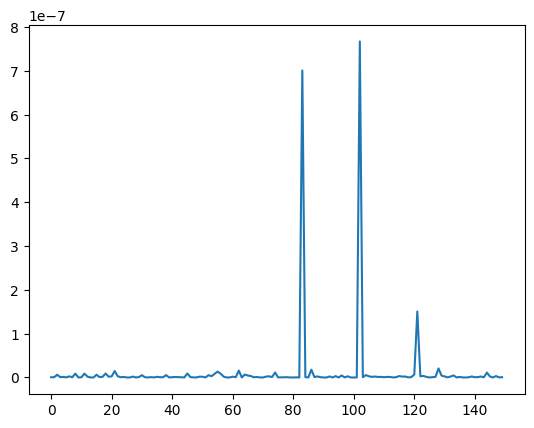

In [15]:
test_factor = tucker.factors[0][0]

plt.plot(test_factor)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_feature_distributions(X, bins=50, cols=10, sharex=False, sharey=False, figsize_per_cell=(2.2, 1.8)):
    """
    X: array-like, shape (n_samples, n_features) = (1000, 100)
    Plots a histogram for each feature/column.
    """
    X = np.asarray(X)
    n_samples, n_features = X.shape

    rows = int(np.ceil(n_features / cols))
    figsize = (figsize_per_cell[0] * cols, figsize_per_cell[1] * rows)

    fig, axes = plt.subplots(
        rows, cols,
        figsize=figsize,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=True
    )
    axes = np.atleast_1d(axes).ravel()

    for j in range(n_features):
        ax = axes[j]
        col = X[:, j]
        col = col[np.isfinite(col)]  # drop NaN/inf if any

        ax.hist(col, bins=bins)
        ax.set_title(f"dim {j}", fontsize=8)
        ax.tick_params(axis="both", labelsize=7)

    # Hide any unused subplots (when n_features not multiple of cols)
    for k in range(n_features, rows * cols):
        axes[k].axis("off")

    # Optional: a single x/y label for the whole figure
    fig.supxlabel("value")
    fig.supylabel("count")

    plt.show()


# Example usage:
# X = np.random.randn(1000, 100)
plot_feature_distributions(tucker.factors[0], bins=80, cols=3)


In [ ]:
plot_feature_distributions(list(alt_extended.extensions["verb"].values()), bins=80, cols=3)

In [ ]:
integrated = alt_extended.integrate_extension(None)
plot_feature_distributions(integrated.factors[0], bins=40, cols=5)


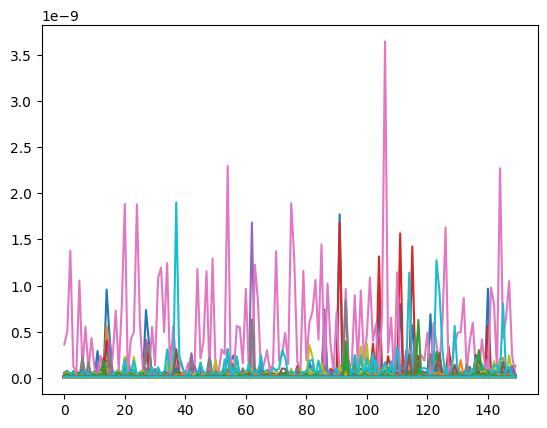

In [125]:
inspection = 700
for i in range(len(tucker.factors[1])):
    plt.plot(tucker.factors[1][i])

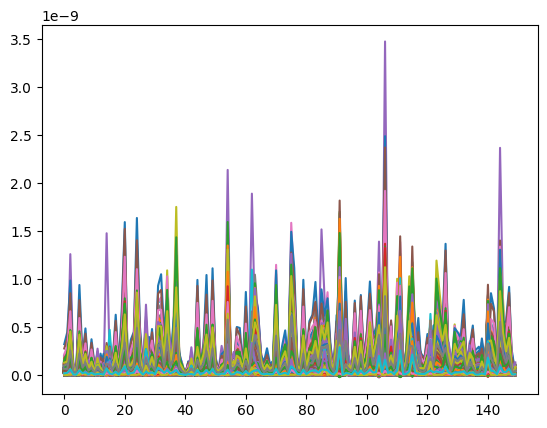

In [126]:
extensions = list(alt_extended_bis.extensions["subject"].values())
for i in range(len(extensions)):
    plt.plot(extensions[-i])

In [ ]:
extensions = list(alt_extended.extensions["verb"].values())
for i in range(len(extensions)):
    plt.plot(extensions[-i])

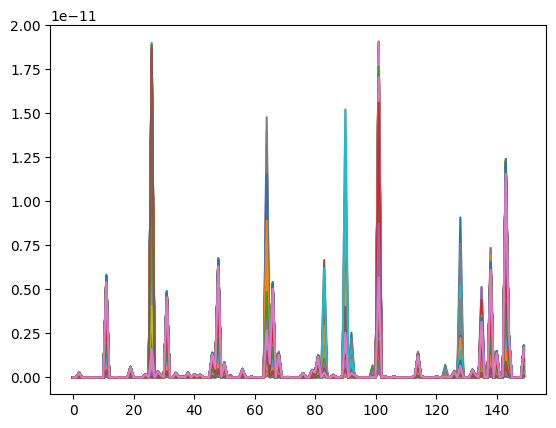

In [110]:
extensions = list(norm_extended.extensions["verb"].values())
for i in range(len(extensions)):
    plt.plot(extensions[-i])

In [ ]:
alt_extended_bis = ExtendedTucker.extend_tucker(
    tucker,
    dataset=full_dataset,
    roles=["verb", "subject"],
    min_count=25,
    fraction_threads=0.66,
    normalize=True,
    normalize_mode="minmax"
)

In [179]:
integrated = alt_extended.integrate_extension(None)

{'verb': 227, 'subject': 5240, 'object': 0}
No extensions for role object


In [141]:
for i in range(3):
    print(integrated.factors[i].shape)

torch.Size([2227, 150])
torch.Size([7240, 150])
torch.Size([2000, 150])


In [142]:
for i in range(10):
    top = integrated.get_top_words_for_dimension("subject", i)
    print("\n", i)
    for el, score in top:
        print(el, el in tucker.vocab["vocab_s"], score)


 0
he True 3.5952546495465754e-10
cinematography False 5.343886444464374e-11
placement True 5.2430084579446756e-11
inclusivity False 4.612038528861717e-11
lack True 4.2734368127517186e-11
adaptability True 3.7831338756122435e-11
interconnectedness False 3.650250587905468e-11
optimization True 3.644459040108572e-11
she True 3.562745584662075e-11
audio False 3.4356628653142707e-11

 1
he True 4.986085988534228e-10
placement True 7.250703509820156e-11
cinematography False 6.709072186694698e-11
optimization True 6.019817977431785e-11
lack True 5.908520894770675e-11
inclusivity False 5.768483607448971e-11
interconnectedness False 4.523400404243816e-11
alignment True 4.24434966339593e-11
adaptability True 4.204693537790405e-11
calibration False 4.1105924220019574e-11

 2
he True 1.379329428452536e-09
she True 5.212508202845356e-11
Chef False 5.119792437224824e-11
cinematography False 4.022185015606361e-11
placement True 3.777998400233962e-11
Quality True 3.6497135175173057e-11
inclusivity F

In [180]:
from similarity import get_most_similar_elements

for word in get_most_similar_elements(tucker, "dog", "subject"):
    print(word in tucker.vocab["vocab_s"], word)

latent from factor
True dog
True cat
True bird
True few
True kid


In [181]:
get_most_similar_elements(tucker, ("bite", "dog", "man"), "subject")

latent from context


['who', 'everyone', 'kid', 'everybody', 'nobody']

In [182]:
for tensor in [tucker, integrated]:
    print(get_most_similar_elements(tensor, ("bite", "dog", "man"), "subject"))


latent from context
['who', 'everyone', 'kid', 'everybody', 'nobody']
latent from context
['I', 'people', 'one', 'member', 'People']


In [192]:
for tensor in [tucker, integrated]:
    print(get_most_similar_elements(tensor, "dog", "subject"))


latent from factor
['dog', 'cat', 'bird', 'few', 'kid']
latent from factor
['dog', 'cat', 'bird', 'few', 'kid']


In [193]:
for el in get_most_similar_elements(integrated, "dog", "subject"):
    print(el in tucker.vocab["vocab_s"], el)

latent from factor
True dog
True cat
True bird
True few
True kid


In [191]:
integrated.factors[1][:5]

tensor([[1.4897e-02, 3.8850e-02, 2.5512e-03, 2.3094e+00, 1.2555e+00, 3.0902e-02,
         3.3403e+01, 4.4087e+00, 7.9749e-02, 2.0018e-08, 2.4031e-02, 1.1369e+02,
         9.5158e-06, 6.6275e+02, 8.0167e+00, 1.1150e+02, 6.4213e-02, 4.7505e-02,
         1.4286e-03, 1.9125e-04, 2.7982e-01, 4.4936e+01, 2.3360e-02, 1.9734e-02,
         1.7825e+00, 2.7487e-03, 3.7756e-03, 1.8478e+02, 4.4993e+02, 1.6121e-02,
         7.3003e+01, 1.2716e-02, 2.1322e-02, 2.7800e-02, 1.3068e-02, 2.8944e+00,
         7.2586e-01, 1.9852e-01, 9.6619e-03, 6.4621e-01, 1.8892e-02, 1.0000e-12,
         1.7069e+01, 3.7373e+00, 2.3467e-03, 4.1485e-03, 9.6065e+00, 2.6916e-03,
         1.0244e+02, 2.1238e-03, 2.5462e+01, 5.7577e+00, 4.7505e+00, 1.3265e-01,
         1.0804e-03, 2.2799e+00, 1.1012e+01, 2.7524e-10, 9.7128e-03, 7.9208e-02,
         2.2526e-03, 5.0346e-04, 1.7256e+01, 5.3044e-03, 1.6185e-01, 6.4952e+02,
         1.3675e-01, 5.4532e-03, 1.7970e+00, 1.7372e-02, 4.7054e-04, 5.0551e-05,
         7.9327e-02, 2.4826e

In [190]:
tucker.factors[1][:5]

tensor([[1.4897e-02, 3.8850e-02, 2.5512e-03, 2.3094e+00, 1.2555e+00, 3.0902e-02,
         3.3403e+01, 4.4087e+00, 7.9749e-02, 2.0018e-08, 2.4031e-02, 1.1369e+02,
         9.5158e-06, 6.6275e+02, 8.0167e+00, 1.1150e+02, 6.4213e-02, 4.7505e-02,
         1.4286e-03, 1.9125e-04, 2.7982e-01, 4.4936e+01, 2.3360e-02, 1.9734e-02,
         1.7825e+00, 2.7487e-03, 3.7756e-03, 1.8478e+02, 4.4993e+02, 1.6121e-02,
         7.3003e+01, 1.2716e-02, 2.1322e-02, 2.7800e-02, 1.3068e-02, 2.8944e+00,
         7.2586e-01, 1.9852e-01, 9.6619e-03, 6.4621e-01, 1.8892e-02, 1.0000e-12,
         1.7069e+01, 3.7373e+00, 2.3467e-03, 4.1485e-03, 9.6065e+00, 2.6916e-03,
         1.0244e+02, 2.1238e-03, 2.5462e+01, 5.7577e+00, 4.7505e+00, 1.3265e-01,
         1.0804e-03, 2.2799e+00, 1.1012e+01, 2.7524e-10, 9.7128e-03, 7.9208e-02,
         2.2526e-03, 5.0346e-04, 1.7256e+01, 5.3044e-03, 1.6185e-01, 6.4952e+02,
         1.3675e-01, 5.4532e-03, 1.7970e+00, 1.7372e-02, 4.7054e-04, 5.0551e-05,
         7.9327e-02, 2.4826e

In [189]:
integrated = extended.integrate_extension(None)

{'verb': 227, 'subject': 5240, 'object': 0}
No extensions for role object


In [216]:
element = "war"
print(element in tucker.vocab["vocab_s"], element in integrated.vocab["vocab_s"])

True True


In [210]:
for tensor in [tucker, integrated]:
    try:
        print(get_most_similar_elements(tensor, "queen", "subject"))
        print(get_most_similar_elements(tensor, ("love", "queen", "war"), "subject"))
    except KeyError:
        continue

latent from factor
['queen', 'fighter', 'medal', 'Swift', 'Earth']
latent from context
['we', 'hath', 'Kirk', 'Carr', 'Treasury']
